In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

In [2]:
MODEL_PATH = "../models/vgg16_pneumonia.keras"

model = tf.keras.models.load_model(MODEL_PATH)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,912,069 (56.89 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 131,588 (514.02 KB)

In [3]:
base_model = model.get_layer("vgg16")

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:
for layer in base_model.layers[-10:]:
    print(layer.name)

block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [5]:
LAST_CONV_LAYER = "block5_conv3"

In [26]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = model.layers[0](inputs)
vgg_out = model.layers[1](x)

x = model.layers[2](vgg_out)
x = model.layers[3](x)
x = model.layers[4](x)
outputs = model.layers[5](x)

cam_model = tf.keras.Model(
    inputs=inputs,
    outputs=[vgg_out, outputs]
)

In [27]:
def make_gradcam_heatmap(img_array):

    with tf.GradientTape() as tape:

        conv_outputs, predictions = cam_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [28]:
IMG_SIZE = (224, 224)

def preprocess_image(img_path):

    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    return img_array

In [29]:
image_path = "../data/test/PNEUMONIA/person100_bacteria_475.jpeg"

img_array = preprocess_image(image_path)

print(img_array.shape)

(1, 224, 224, 3)


In [30]:
heatmap = make_gradcam_heatmap(img_array)

print("Shape:", heatmap.shape)
print("Min:", heatmap.min())
print("Max:", heatmap.max())

Shape: (7, 7)
Min: 0.0
Max: 1.0


In [31]:
def overlay_gradcam(img_path, heatmap):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    heatmap = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap_colored = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap_colored = cv2.cvtColor(
        heatmap_colored,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        img,
        0.6,
        heatmap_colored,
        0.4,
        0
    )

    return img, heatmap_colored, overlay

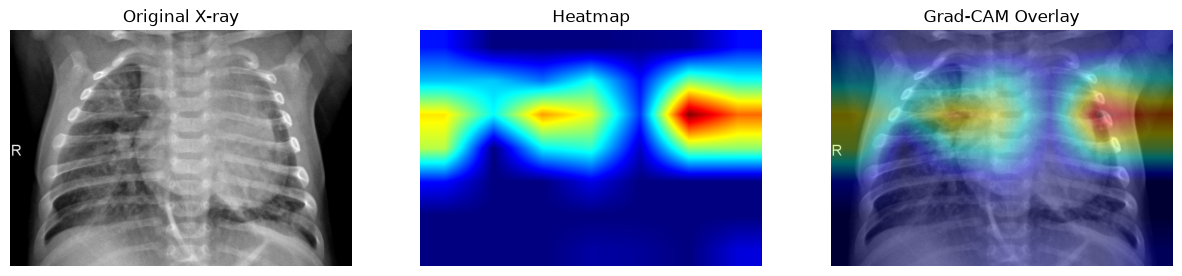

In [32]:
original, cam, overlay = overlay_gradcam(
    image_path,
    heatmap
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam)
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

In [33]:
import os

os.makedirs("../reports/gradcam_examples", exist_ok=True)

print("Folder created")

Folder created


In [39]:
def save_gradcam_panel(img_path, save_path):

    img_array = preprocess_image(img_path)

    heatmap = make_gradcam_heatmap(img_array)

    original, cam, overlay = overlay_gradcam(
        img_path,
        heatmap
    )

    fig, ax = plt.subplots(
        1, 3,
        figsize=(15, 5)
    )

    ax[0].imshow(original)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(cam)
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Grad-CAM")
    ax[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        save_path,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {save_path}")

In [ ]:
import os

pneumonia_folder = "../data/test/PNEUMONIA"

pneumonia_images = sorted(
    os.listdir(pneumonia_folder)
)[:2]

for i, file in enumerate(pneumonia_images, start=1):

    image_path = os.path.join(
        pneumonia_folder,
        file
    )

    save_path = (
        f"../reports/gradcam_examples/"
        f"gradcam_pneumonia_{i}.jpg"
    )

    save_gradcam(
        image_path,
        save_path
    )

IndentationError: expected an indented block after function definition on line 21 (4269003249.py, line 23)

In [36]:
normal_folder = "../data/test/NORMAL"

normal_images = sorted(
    os.listdir(normal_folder)
)[:2]

for i, file in enumerate(normal_images, start=1):

    image_path = os.path.join(
        normal_folder,
        file
    )

    save_path = (
        f"../reports/gradcam_examples/"
        f"gradcam_normal_{i}.jpg"
    )

    save_gradcam(
        image_path,
        save_path
    )

Saved: ../reports/gradcam_examples/gradcam_normal_1.jpg
Saved: ../reports/gradcam_examples/gradcam_normal_2.jpg


In [37]:
import os

print(
    os.listdir(
        "../reports/gradcam_examples"
    )
)

['gradcam_normal_1.jpg', 'gradcam_normal_2.jpg', 'gradcam_pneumonia_1.jpg', 'gradcam_pneumonia_2.jpg']
